Required libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os

Data collection and data understanding

In [3]:
ds=pd.read_csv("xy_data.csv")
print(ds.head())

            x          y
0   88.364456  57.784378
1   74.283936  54.406780
2   60.256474  46.311462
3   82.134370  57.717567
4  101.036390  67.849340


In [4]:
ds.shape

(1500, 2)

In [5]:
ax=ds["x"].values
ay=ds["y"].values

print(ax)
print(ay)

[88.364456 74.283936 60.256474 ... 83.44702  63.372417 66.02347 ]
[57.784378 54.40678  46.311462 ... 57.53351  47.135735 47.49617 ]


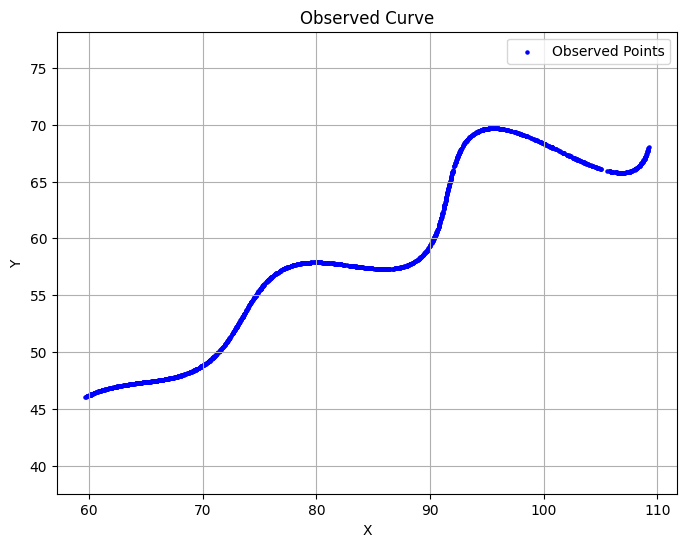

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(ax, ay,s=5,color="blue",label="Observed Points")
plt.title("Observed Curve")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

theta → Rotation

M → Controls exponential growth/decay

X → Horizontal translation

In [7]:
def generate_curve(th,M,X,t):
  th=np.radians(th)
  x=(t*np.cos(th)-np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(th)+X)
  y=(42+t*np.sin(th)+np.exp(M*np.abs(t))*np.sin(0.3*t)*np.cos(th))
  return x,y


In [8]:
# t value
t=np.linspace(6,60,len(ax))

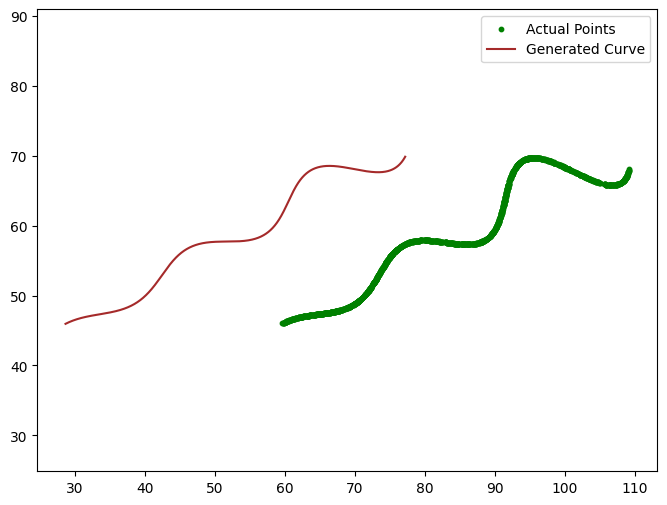

In [9]:
px,py=generate_curve(th=30,M=0.02,X=24,t=t)

plt.figure(figsize=(8,6))
plt.scatter(ax,ay,color="green",s=10,label="Actual Points")
plt.plot(px,py,color="brown",label="Generated Curve")
plt.axis("equal")
plt.legend()
plt.show()

In [10]:
# L1 distance

def L1_error(ax,ay,px,py):
  e_x=np.abs(ax-px)
  e_y=np.abs(ay-py)

  return np.sum(e_x+e_y)

In [17]:
os.makedirs("frames",exist_ok=True)

In [18]:
best_err = float('inf')

best_th = None
best_M = None
best_X = None

frame=0
history=[]

In [19]:
for th in range(1,51):
  if th % 5 == 0:
    print(f"Checking theta = {th}")
  for M in np.arange(-0.05,0.051,0.001):
    for X in range(0,101,2):
      px,py=generate_curve(th=th,M=M,X=X,t=t)
      err=L1_error(ax,ay,px,py)
      if err<best_err:
        print("Better solution found!")
        best_err=err
        best_th=th
        best_M=M
        best_X=X

        frame+=1

        history.append({"Iteration": frame,
                        "Theta":best_th,
                        "M":best_M,
                        "X":best_X,
                        "Error":best_err})
        plt.figure(figsize=(8,6))
        plt.scatter(ax,ay,color="green",s=10,label="Actual Points")
        plt.plot(px,py,color="brown",label="Generated Curve")

        plt.title(f"Iteration {frame}\n" f"Theta= {best_th:.2f}" f"M= {best_M:.4f}" f"X= {best_X:.2f}\n" f"Error= {best_err:.2f}")
        plt.axis("equal")
        plt.legend()
        plt.savefig(f"frames/frame_{frame:04d}.png")
        plt.close()


Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Better solution found!
Checking theta = 5
Better solution found!
Better solution found!
Better solution found!
Better solution

In [20]:
import os

print("Frames Saved:", len(os.listdir("frames")))

Frames Saved: 499


In [21]:
print("Brute Force Method")
print("Best Error:",best_err)
print("Best th:",best_th)
print("Best M:",best_M)
print("Best X:",best_X)

Brute Force Method
Best Error: 37883.707174034666
Best th: 28
Best M: 0.02100000000000006
Best X: 54


Refined Brute Force Search

In [22]:
n_th = best_th
n_M = best_M
n_X = best_X

# Reset error
best_err = float("inf")
for th in np.arange(n_th - 2, n_th + 2.1, 0.1):
    for M in np.arange(n_M - 0.005, n_M + 0.0051, 0.0005):
        for X in np.arange(n_X - 2, n_X + 2.1, 0.1):
            x_val, y_val = generate_curve(th, M, X, t)
            err = L1_error(ax, ay, px, py)
            if err < best_err:
                best_err = err
                best_th = th
                best_M = M
                best_X = X

print("\nRefined Search Results")
print("Best Error:", best_err)
print("Best Theta:", best_th)
print("Best M:", best_M)
print("Best X:", best_X)


Refined Search Results
Best Error: 77326.99634534746
Best Theta: 26.0
Best M: 0.01600000000000006
Best X: 52.0


In [23]:
print()
print("Refined Search")
print("Best Error:",best_err)
print("Theta:",best_th)
print("M:",best_M)
print("X:",best_X)


Refined Search
Best Error: 77326.99634534746
Theta: 26.0
M: 0.01600000000000006
X: 52.0


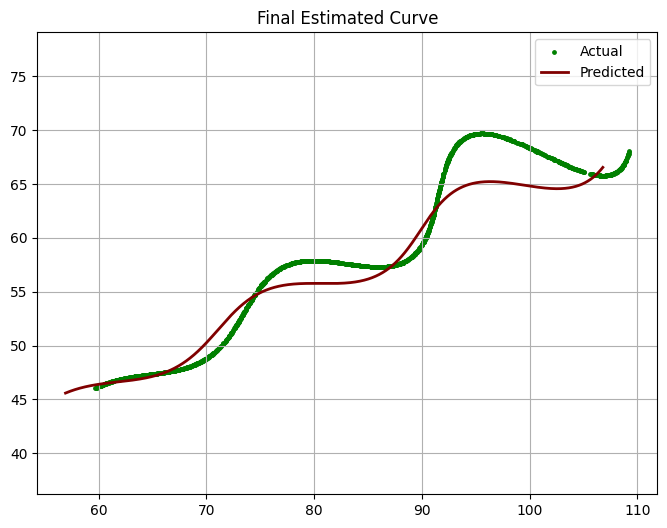

In [25]:
final_x, final_y = generate_curve(
    best_th,
    best_M,
    best_X,
    t
)

plt.figure(figsize=(8,6))

plt.scatter(ax,ay,s=6,color="green",label="Actual")

plt.plot(final_x,final_y,color="maroon",linewidth=2,label="Predicted")
plt.title("Final Estimated Curve")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [26]:
# Saving Parameter History
history = pd.DataFrame(history)
history.to_csv("parameter_history.csv",index=False)
print(history.head())

   Iteration  Theta     M  X         Error
0          1      1 -0.05  0  99616.093220
1          2      1 -0.05  2  96617.969877
2          3      1 -0.05  4  93637.117473
3          4      1 -0.05  6  90675.605890
4          5      1 -0.05  8  87753.693081


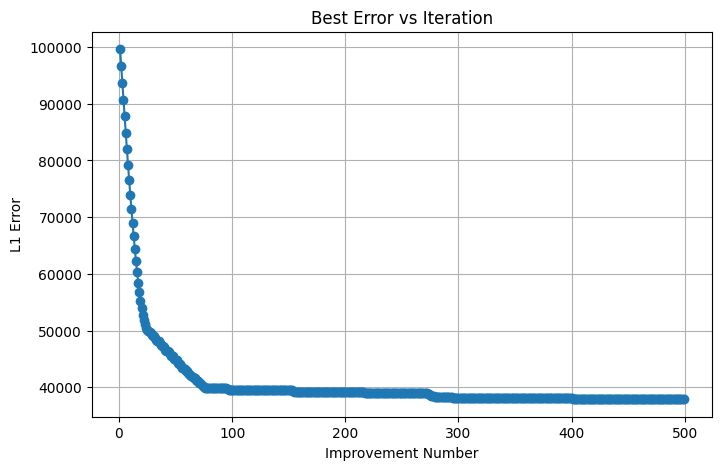

In [28]:
plt.figure(figsize=(8,5))
plt.plot(history["Iteration"], history["Error"],marker="o")
plt.title("Best Error vs Iteration")
plt.xlabel("Improvement Number")
plt.ylabel("L1 Error")
plt.grid(True)
plt.show()

In [29]:
images = []

for file in sorted(os.listdir("frames")):

    images.append(
        imageio.imread(
            "frames/"+file
        )
    )

imageio.mimsave(
    "curve_search.gif",
    images,
    fps=4
)

print("GIF Saved Successfully!")

GIF Saved Successfully!


In [30]:
print("=" * 50)
print("FINAL PARAMETER ESTIMATION")
print("=" * 50)
print(f"Theta (θ) : {best_th:.3f}°")
print(f"M         : {best_M:.5f}")
print(f"X         : {best_X:.3f}")
print(f"Minimum L1 Error : {best_err:.3f}")
print("=" * 50)

FINAL PARAMETER ESTIMATION
Theta (θ) : 26.000°
M         : 0.01600
X         : 52.000
Minimum L1 Error : 77326.996
